In [1]:
loss='logcosh'

In [2]:

f = '/home/miglab/loss function project/pancreas segmentation/loaded_models/unet_logcosh_0.4747.keras'

In [3]:
from keras.layers import Input,Dense,Flatten,Dropout,Reshape,Conv2D,MaxPooling2D,UpSampling2D,Conv2DTranspose
from keras.layers import Activation
from keras.layers import concatenate
from keras.layers import BatchNormalization
from keras.models import Model
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam
from keras import backend as K
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import tifffile
import cv2
import pandas as pd


2024-09-13 02:52:48.872901: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-13 02:52:48.893359: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-13 02:52:48.893384: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-13 02:52:48.894315: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-13 02:52:48.898466: I tensorflow/core/platform/cpu_feature_guar

In [4]:

import tensorflow as tf
import keras
print('Tensorflow version:', tf.__version__)
print('Keras version:', keras.__version__)

Tensorflow version: 2.15.1
Keras version: 2.15.0


In [5]:
from tensorflow.keras import backend as K
K.clear_session()

In [6]:
!nvidia-smi

Fri Sep 13 02:52:49 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.01             Driver Version: 535.183.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA RTX A5000               Off | 00000000:01:00.0  On |                  Off |
| 44%   60C    P3              58W / 230W |    496MiB / 24564MiB |     13%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [7]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


2024-09-13 02:52:50.160701: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-09-13 02:52:50.163954: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-09-13 02:52:50.164030: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [8]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable memory growth for each GPU
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth set for all GPUs.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)


Memory growth set for all GPUs.


In [9]:
df_dir = '/home/miglab/loss function project/pancreas segmentation/Image_data/'
train_df = pd.read_csv(df_dir+'train_pathspanc.csv')
val_df = pd.read_csv(df_dir+'val_pathspanc.csv')

In [10]:
# List of index positions to copy (as per your example)
index_positions = [5408, 1203, 2004, 4334]

# Copy the rows with the specific index positions to a new DataFrame
new_val_df = val_df.loc[index_positions]

# Display the new DataFrame
print(new_val_df)


                                         image_path  \
5408  Image_data/Val/imagesVal/pancreas_217_60.tiff   
1203  Image_data/Val/imagesVal/pancreas_101_70.tiff   
2004  Image_data/Val/imagesVal/pancreas_086_31.tiff   
4334  Image_data/Val/imagesVal/pancreas_096_47.tiff   

                                         label_path  
5408  Image_data/Val/labelsVal/pancreas_217_60.tiff  
1203  Image_data/Val/labelsVal/pancreas_101_70.tiff  
2004  Image_data/Val/labelsVal/pancreas_086_31.tiff  
4334  Image_data/Val/labelsVal/pancreas_096_47.tiff  


In [11]:
train_df = train_df.sample(frac=1,random_state=7) 
val_df =  val_df.sample(frac=1,random_state=7)

In [12]:
train_samples = len(train_df)
val_samples = len(val_df)

print(" Training Samples: ",train_samples,'\n',"Validation Samples: ",val_samples)

 Training Samples:  21185 
 Validation Samples:  5534


In [13]:
# List of index positions to copy (as per your example)
m = [5408, 1203, 2004, 4334]

# Copy the rows with the specific index positions to a new DataFrame
new_val_df1 = val_df.loc[index_positions]

# Display the new DataFrame
print(new_val_df1)

                                         image_path  \
5408  Image_data/Val/imagesVal/pancreas_217_60.tiff   
1203  Image_data/Val/imagesVal/pancreas_101_70.tiff   
2004  Image_data/Val/imagesVal/pancreas_086_31.tiff   
4334  Image_data/Val/imagesVal/pancreas_096_47.tiff   

                                         label_path  
5408  Image_data/Val/labelsVal/pancreas_217_60.tiff  
1203  Image_data/Val/labelsVal/pancreas_101_70.tiff  
2004  Image_data/Val/labelsVal/pancreas_086_31.tiff  
4334  Image_data/Val/labelsVal/pancreas_096_47.tiff  


In [14]:
train_df.head()

,image_path,label_path
16408,Image_data/Train/imagesTr/pancreas_228_37.tiff,Image_data/Train/labelsTr/pancreas_228_37.tiff
6231,Image_data/Train/imagesTr/pancreas_280_7.tiff,Image_data/Train/labelsTr/pancreas_280_7.tiff
19769,Image_data/Train/imagesTr/pancreas_308_58.tiff,Image_data/Train/labelsTr/pancreas_308_58.tiff
9051,Image_data/Train/imagesTr/pancreas_004_68.tiff,Image_data/Train/labelsTr/pancreas_004_68.tiff
4095,Image_data/Train/imagesTr/pancreas_051_71.tiff,Image_data/Train/labelsTr/pancreas_051_71.tiff


In [15]:
def load(files,mask=False):
    images =[]
    for file in files:
        if not mask:
            img = tifffile.imread('/home/miglab/loss function project/pancreas segmentation/'+file)/255
            images.append(img)
        else:
            img = tifffile.imread('/home/miglab/loss function project/pancreas segmentation/'+file)
            images.append(img)
    return np.asarray(images)

In [16]:
def noise_add(labels,noise_ratio):
    flip_indices =np.random.choice(len(labels),size=int(len(labels)*noise_ratio))
    labels[flip_indices]=1-labels[flip_indices]
    return labels

In [17]:
def imageLoader(df,batch_size,noise=0):

    L = len(df)
    

    #keras needs the generator infinite, so we will use while true  
    while True:

        batch_start = 0
        batch_end = batch_size

        while batch_start < L:
            limit = min(batch_end, L)
            
            X = load(df['image_path'][batch_start:limit])
            Y = load(df['label_path'][batch_start:limit],mask=True)
            Y = noise_add(Y,noise)
            
            yield (X,Y) #a tuple with two numpy arrays with batch_size samples     

            batch_start += batch_size   
            batch_end += batch_size

# Metrics

In [18]:
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon())

def jaccard_index(y_true, y_pred):
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection
    return (intersection + K.epsilon()) / (union + K.epsilon())

def precision(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    return true_positives / (predicted_positives + K.epsilon())

def recall(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    total_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    return true_positives / (total_positives + K.epsilon())

def hausdorff_distance(y_true, y_pred):
    surface_distances = tf.reduce_sum(y_true * y_pred, axis=[1, 2]) / tf.reduce_sum(y_true + y_pred, axis=[1, 2])
    hausdorff_distance = tf.reduce_max(surface_distances)
    return hausdorff_distance

def specificity(y_true, y_pred):
    true_negatives = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    total_negatives = K.sum(K.round(K.clip(1 - y_true, 0, 1)))
    return true_negatives / (total_negatives + K.epsilon())

def f1_score(y_true, y_pred):
    precision_value = precision(y_true, y_pred)
    recall_value = recall(y_true, y_pred)
    f1 = 2 * (precision_value * recall_value) / (precision_value + recall_value + K.epsilon())
    return f1

def dpce(y_true, y_pred, distance_fn=tf.keras.losses.MSE):
    ce_loss = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)  # Compute standard cross entropy loss

    # Calculate the distance penalty using the specified distance function
    distance_loss = distance_fn(y_true, y_pred)

    # Combine the cross entropy loss and distance penalty
    loss = ce_loss + distance_loss

    return loss

def accuracy(y_true, y_pred):
    correct_predictions = tf.equal(tf.round(y_pred), y_true)
    accuracy = tf.reduce_mean(tf.cast(correct_predictions, tf.float32))
    return accuracy


In [19]:


metrics = [dice_coef,jaccard_index,hausdorff_distance,precision,dpce,recall,specificity,f1_score,accuracy]

# Losses

In [20]:


beta = 0.25
alpha = 0.25
gamma = 2
epsilon = 1e-5
smooth = 1

def dice_loss(y_true, y_pred):
    return 1-dice_coef(y_true, y_pred)


def logcosh_loss(y_true, y_pred):
    loss = tf.math.log(tf.math.cosh(y_pred - y_true))
    return tf.reduce_mean(loss)

def log_dice(y_true,y_pred):
    dice_loss_value = dice_loss(y_true,y_pred)
    return tf.math.log(tf.math.cosh(dice_loss_value))



def tversky_index(y_true, y_pred):
    y_true_pos = K.flatten(y_true)
    y_pred_pos = K.flatten(y_pred)
    true_pos = K.sum(y_true_pos * y_pred_pos)
    false_neg = K.sum(y_true_pos * (1 - y_pred_pos))
    false_pos = K.sum((1 - y_true_pos) * y_pred_pos)
    alpha = 0.5
    return (true_pos + smooth) / (true_pos + alpha * false_neg + ( 1 - alpha) * false_pos + smooth)


def tversky_loss(y_true, y_pred):
    return 1 - tversky_index(y_true, y_pred)


def focal_tversky(y_true, y_pred, alpha=0.5, gamma=4/3, const=K.epsilon()):
    
    '''
    Focal Tversky Loss (FTL)
    
    focal_tversky(y_true, y_pred, alpha=0.5, gamma=4/3)
    
    ----------
    Abraham, N. and Khan, N.M., 2019, April. A novel focal tversky loss function with improved 
    attention u-net for lesion segmentation. In 2019 IEEE 16th International Symposium on Biomedical Imaging 
    (ISBI 2019) (pp. 683-687). IEEE.
    
    ----------
    Input
        alpha: tunable parameter within [0, 1]. Alpha handles imbalance classification cases 
        gamma: tunable parameter within [1, 3].
        const: a constant that smooths the loss gradient and reduces numerical instabilities.
        
    '''
    # tf tensor casting
    y_pred = tf.convert_to_tensor(y_pred)
    y_true = tf.cast(y_true, y_pred.dtype)
    
    # <--- squeeze-out length-1 dimensions.
    y_pred = tf.squeeze(y_pred)
    y_true = tf.squeeze(y_true)
    
    # (Tversky loss)**(1/gamma) 
    loss_val = tf.math.pow((1-tversky_index(y_true, y_pred)), 1/gamma)
    
    return loss_val


Bin_loss = tf.keras.losses.BinaryCrossentropy()





















In [21]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.losses import BinaryCrossentropy

# Jaccard Similarity (IoU)
def jaccard_similarity(y_true, y_pred):
    """
    Intersection-Over-Union (IoU), also known as the Jaccard Index
    """
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f + y_pred_f) - intersection
    return intersection / (union + K.epsilon())  # Add small epsilon to avoid division by zero

# Jaccard Loss
def jaccard_loss(y_true, y_pred):
    """
    Jaccard loss, complementary to Jaccard similarity (IoU)
    """
    return 1 - jaccard_similarity(y_true, y_pred)
import tensorflow as tf

def ssim_loss(y_true, y_pred):
    """
    Structural Similarity Index (SSIM) loss with padding and ensuring 4D tensors
    """
    # Ensure y_true and y_pred are 4D tensors by adding the batch or channel dimension
    if len(y_true.shape) == 3:
        y_true = tf.expand_dims(y_true, axis=-1)  # Add channel dimension if missing
    if len(y_pred.shape) == 3:
        y_pred = tf.expand_dims(y_pred, axis=-1)

    # Pad input tensors to handle larger filter size
    y_true_padded = tf.pad(y_true, [[0, 0], [2, 2], [2, 2], [0, 0]], mode="REFLECT")
    y_pred_padded = tf.pad(y_pred, [[0, 0], [2, 2], [2, 2], [0, 0]], mode="REFLECT")

    # Now apply SSIM with the padded inputs
    return 1 - tf.image.ssim(y_true_padded, y_pred_padded, max_val=1, filter_size=5)

# BASNET Hybrid Loss
def basnet_hybrid_loss(y_true, y_pred):
    """
    Hybrid loss proposed in BASNET (https://arxiv.org/pdf/2101.04704.pdf)
    The hybrid loss is a combination of binary cross-entropy, structural similarity,
    and intersection-over-union (Jaccard) losses.
    """
    # Binary Crossentropy loss
    bce_loss_fn = BinaryCrossentropy(from_logits=False)
    bce_loss = bce_loss_fn(y_true, y_pred)

    # SSIM loss
    ms_ssim_loss = ssim_loss(y_true, y_pred)

    # Jaccard loss
    jaccard = jaccard_loss(y_true, y_pred)

    # Return the combined loss
    return bce_loss + ms_ssim_loss + jaccard


In [22]:
losses = {
    'dice': dice_loss,
    'logcosh': logcosh_loss,
    'logdice': log_dice,
   # 'focal':focal_loss,
    'tversky': tversky_loss,
    'focal_tversky': focal_tversky,
    'bce': Bin_loss,
    
    'hybrid':basnet_hybrid_loss
    }

In [23]:
from keras.models import load_model

l_model = load_model(f,custom_objects={'logcosh_loss': logcosh_loss,
                                                    'dice_coef': dice_coef,
                                                    'jaccard_index': jaccard_index,
                                                    'hausdorff_distance': hausdorff_distance,
                                                    'precision': precision,
                                                    'dpce': dpce,
                                                    'recall': recall,
                                                    'specificity': specificity,
                                                    'f1_score': f1_score,
                                                    'accuracy':accuracy})

l_eval = l_model.evaluate(imageLoader(val_df,64),steps=val_samples//64,return_dict=True)
l_eval

2024-09-13 02:52:50.274165: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-09-13 02:52:50.274260: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-09-13 02:52:50.274299: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

86/86 [==============================] - 37s 229ms/step - loss: 3.9853e-04 - dice_coef: 0.4809 - jaccard_index: 0.3178 - hausdorff_distance: 0.3992 - precision: 0.7188 - dpce: 0.0051 - recall: 0.6451 - specificity: 0.9995 - f1_score: 0.6763 - accuracy: 0.9989


{'loss': 0.0003985348157584667,
 'dice_coef': 0.480940043926239,
 'jaccard_index': 0.31776610016822815,
 'hausdorff_distance': 0.399179071187973,
 'precision': 0.7187870740890503,
 'dpce': 0.0051090531051158905,
 'recall': 0.6450974941253662,
 'specificity': 0.9995336532592773,
 'f1_score': 0.6762826442718506,
 'accuracy': 0.9988664984703064}

In [24]:
# Load all the images and labels from the validation set
x_eval = load(val_df['image_path'])  # Load all validation images
y_eval = load(val_df['label_path'], mask=True)  # Load all corresponding labels

print(x_eval.shape, y_eval.shape)  # To verify the shapes of the loaded images and labels


(5534, 512, 512) (5534, 512, 512)


In [25]:
y_pred = l_model.predict(x_eval)

173/173 [==============================] - 35s 153ms/step


2024-09-13 02:54:15.891284: W external/local_tsl/tsl/framework/bfc_allocator.cc:366] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


In [26]:
q=[440,480,1270,2450]

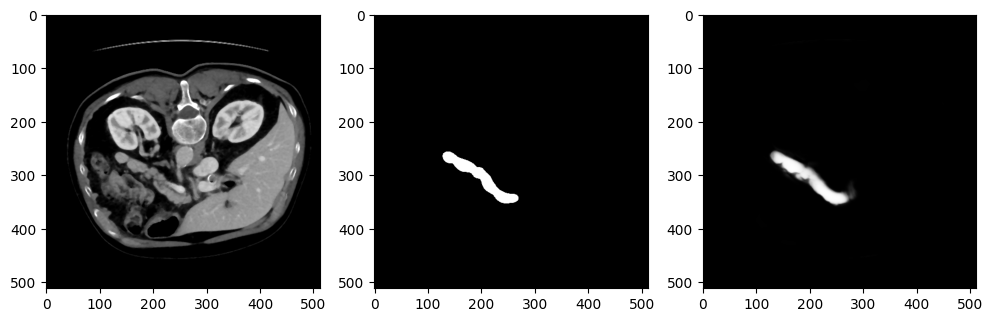

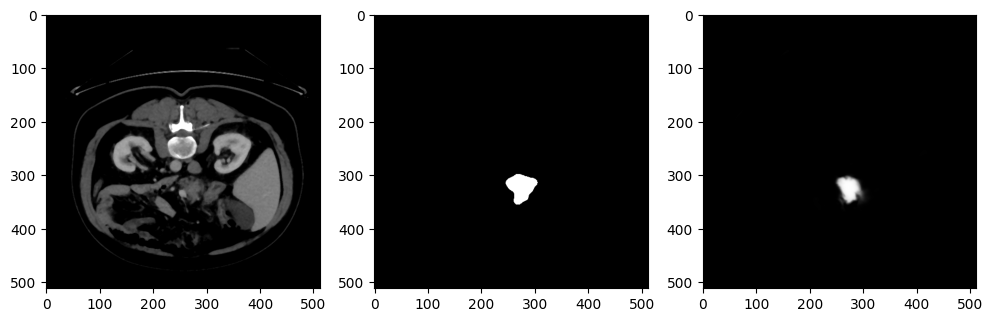

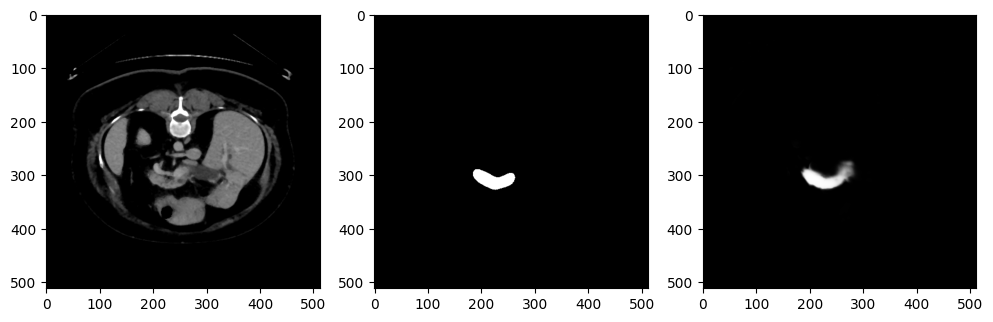

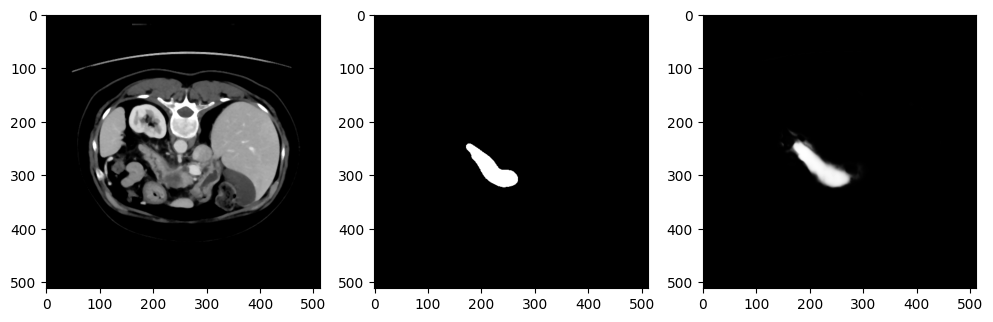

In [27]:
for i in range(0,4,1):
    fig, ax = plt.subplots(1,3,figsize=(12,6))
    ax[0].imshow(x_eval[q[i],:,:], cmap='gray')
    ax[1].imshow(y_eval[q[i],:,:], cmap='gray')
    ax[2].imshow(y_pred[q[i],:,:], cmap='gray')
plt.show()

In [28]:
y_pred.shape

(5534, 512, 512, 1)

In [29]:
if y_pred.shape[-1] == 1:
    y_pred = np.squeeze(y_pred, axis=-1)
print(y_pred.shape)


(5534, 512, 512)


In [31]:
import tensorflow as tf
import numpy as np
import tifffile
from tqdm import tqdm  # Import tqdm for progress monitoring

# Assuming the same data loading functions as you have provided.
def load(files, mask=False):
    images = []
    for file in files:
        if not mask:
            img = tifffile.imread('/home/miglab/loss function project/pancreas segmentation/' + file) / 255
            images.append(img)
        else:
            img = tifffile.imread('/home/miglab/loss function project/pancreas segmentation/' + file)
            images.append(img)
    return np.asarray(images)

def imageLoader(df, batch_size, noise=0):
    L = len(df)

    while True:
        batch_start = 0
        batch_end = batch_size

        while batch_start < L:
            limit = min(batch_end, L)
            
            X = load(df['image_path'][batch_start:limit])
            Y = load(df['label_path'][batch_start:limit], mask=True)
            Y = noise_add(Y, noise)
            
            yield (X, Y)

            batch_start += batch_size   
            batch_end += batch_size

# Define the MCDropoutModel class as before
class MCDropoutModel(tf.keras.Model):
    def __init__(self, model):
        super(MCDropoutModel, self).__init__()
        self.model = model

    def call(self, inputs, training=False):
        return self.model(inputs, training=training)

mc_model = MCDropoutModel(l_model)

# Modify this function to handle batched predictions with tqdm
def predict_with_dropout_batch(model, data_generator, steps, batch_size, num_samples):
    all_mean_predictions = []
    all_variance_predictions = []
    all_uncertainty_maps = []

    # Wrap the loop with tqdm for progress bar
    with tqdm(total=steps, desc="Processing Batches") as pbar:
        for step in range(steps):
            # Load the next batch of images
            x_batch, _ = next(data_generator)

            # Monte Carlo Dropout
            predictions = []
            for _ in range(num_samples):
                predictions.append(model(x_batch, training=True))

            predictions = tf.stack(predictions)

            # Calculate mean and variance across Monte Carlo samples
            mean_prediction = tf.reduce_mean(predictions, axis=0)
            variance_prediction = tf.math.reduce_variance(predictions, axis=0)

            # Uncertainty map (using entropy)
            uncertainty_map = -tf.reduce_sum(mean_prediction * tf.math.log(mean_prediction + 1e-8), axis=-1)

            # Collect results for this batch
            all_mean_predictions.append(mean_prediction.numpy())
            all_variance_predictions.append(variance_prediction.numpy())
            all_uncertainty_maps.append(uncertainty_map.numpy())

            # Update the progress bar
            pbar.update(1)

    # Concatenate all the batches back together
    all_mean_predictions = np.concatenate(all_mean_predictions, axis=0)
    all_variance_predictions = np.concatenate(all_variance_predictions, axis=0)
    all_uncertainty_maps = np.concatenate(all_uncertainty_maps, axis=0)

    return all_mean_predictions, all_variance_predictions, all_uncertainty_maps

# Now define how to run the entire process on the validation dataset

batch_size = 32  # Set this to a size that fits into your GPU memory
num_samples = 50  # Number of Monte Carlo dropout samples
steps = len(val_df) // batch_size + int(len(val_df) % batch_size != 0)  # Total number of steps

# Initialize the data generator
val_data_generator = imageLoader(val_df, batch_size)

# Run Monte Carlo Dropout prediction in batches
mean_predictions, variance_predictions, uncertainty_maps = predict_with_dropout_batch(
    mc_model, val_data_generator, steps, batch_size, num_samples
)

# Now you have the mean predictions, variance, and uncertainty maps for the entire dataset


Processing Batches:   0%|          | 0/173 [00:00<?, ?it/s]2024-09-13 02:55:22.614356: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.44GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2024-09-13 02:55:22.922554: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.44GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2024-09-13 02:55:25.711651: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.52GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2024-09-

In [32]:
# Inspect the shape of mean_predictions

# If the last dimension is 1, then squeeze. Otherwise, skip squeezing.
if mean_predictions.shape[-1] == 1:
    mean_predictions = np.squeeze(mean_predictions, axis=-1)

print(mean_predictions.shape)  # Verify the final shape


(5534, 512, 512)


In [33]:
mean_predictions.shape

(5534, 512, 512)

In [34]:
mean_predictions.shape

(5534, 512, 512)

In [35]:
x_eval.shape

(5534, 512, 512)

In [36]:
y_eval.shape

(5534, 512, 512)

In [37]:
y_pred.shape

(5534, 512, 512)

In [38]:
import numpy as np
from tqdm import tqdm

# Define the Dice coefficient calculation function
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)
    return dice

# Define the batch processing function with tqdm progress bar
def calculate_dice_in_batches(y_eval, mean_predictions, batch_size=16):
    dice_scores = []
    num_batches = int(np.ceil(len(y_eval) / batch_size))  # Calculate number of batches
    
    # Initialize tqdm progress bar
    with tqdm(total=num_batches, desc="Calculating Dice Coefficients", unit="batch") as pbar:
        for batch_idx in range(num_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, len(y_eval))

            # Extract batch
            y_true_batch = y_eval[start_idx:end_idx]
            y_pred_batch = mean_predictions[start_idx:end_idx]

            # Calculate Dice coefficient for each image in the batch
            for y_true, y_pred in zip(y_true_batch, y_pred_batch):
                dice = dice_coefficient(y_true, y_pred)
                dice_scores.append(dice)
            
            pbar.update(1)  # Update tqdm progress bar
    
    return dice_scores

# Example of how to use this code (assuming y_eval and mean_predictions are defined)

# Binarize predictions using threshold
threshold = 0.5
mean_prediction_binary = (mean_predictions >= threshold).astype(bool)  # Fixed np.bool issue

# Adjust batch size
batch_size = 16

# Calculate Dice coefficients in batches
dice_scores = calculate_dice_in_batches(y_eval, mean_prediction_binary, batch_size=batch_size)

# Average Dice coefficient
average_dice = np.mean(dice_scores)

# Output results
print("Average Dice Coefficient:", average_dice)
print("Mean of predictions:", np.mean(mean_predictions))

# Check if uncertainty_maps is defined, if not, avoid printing
if 'uncertainty_maps' in globals():
    print("Mean of uncertainty:", np.mean(uncertainty_maps))
else:
    print("Uncertainty maps not defined.")


Calculating Dice Coefficients: 100%|██████████| 346/346 [00:01<00:00, 255.87batch/s]


Average Dice Coefficient: 0.837848758071614
Mean of predictions: 0.0029001143
Mean of uncertainty: 0.008645402


In [39]:
c=[5408,1203,2004,4334]

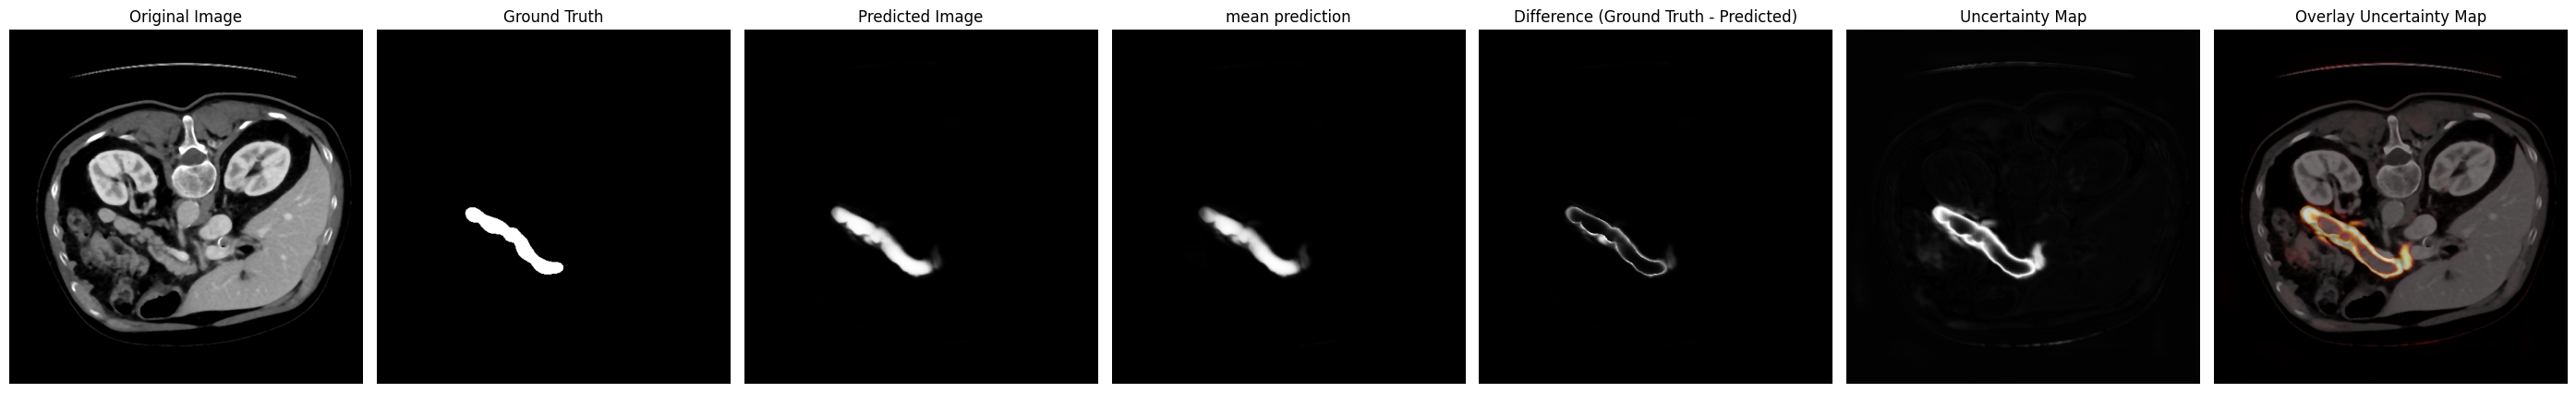

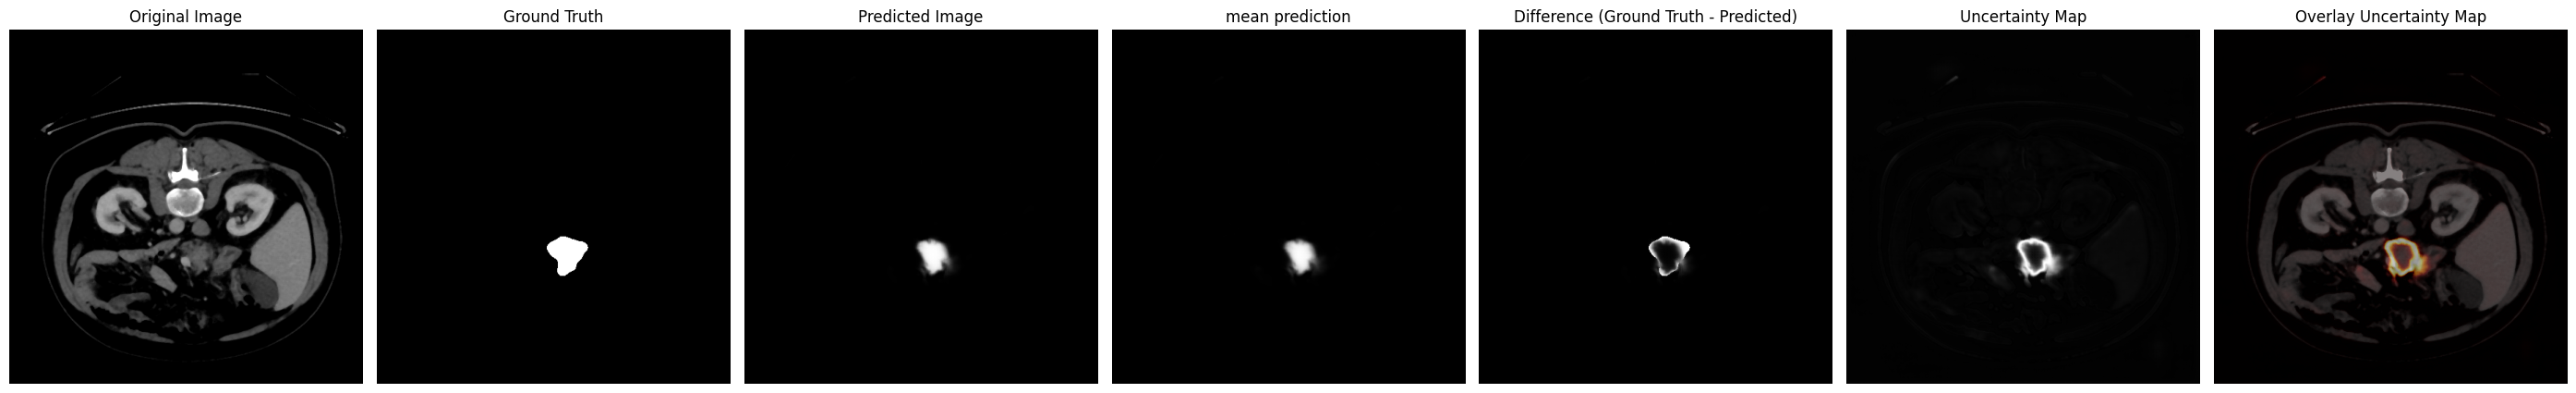

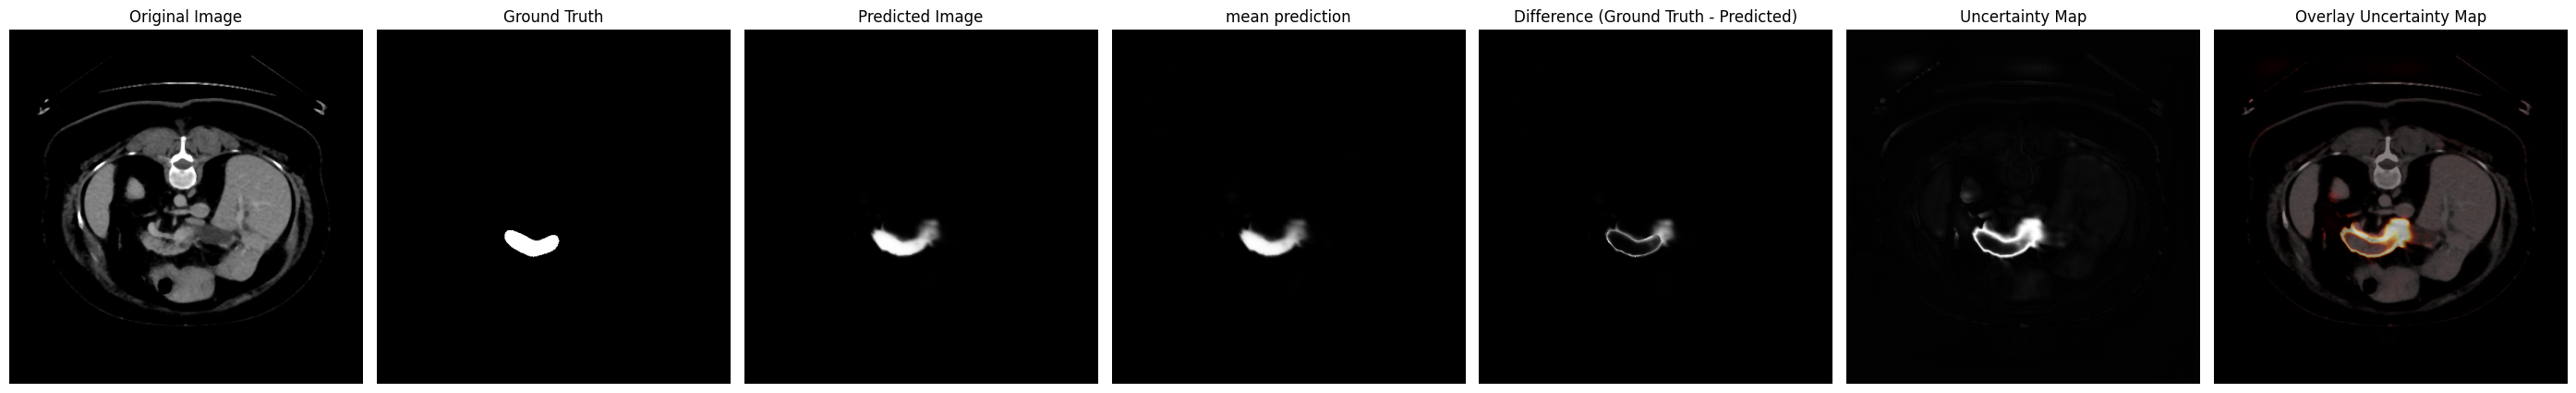

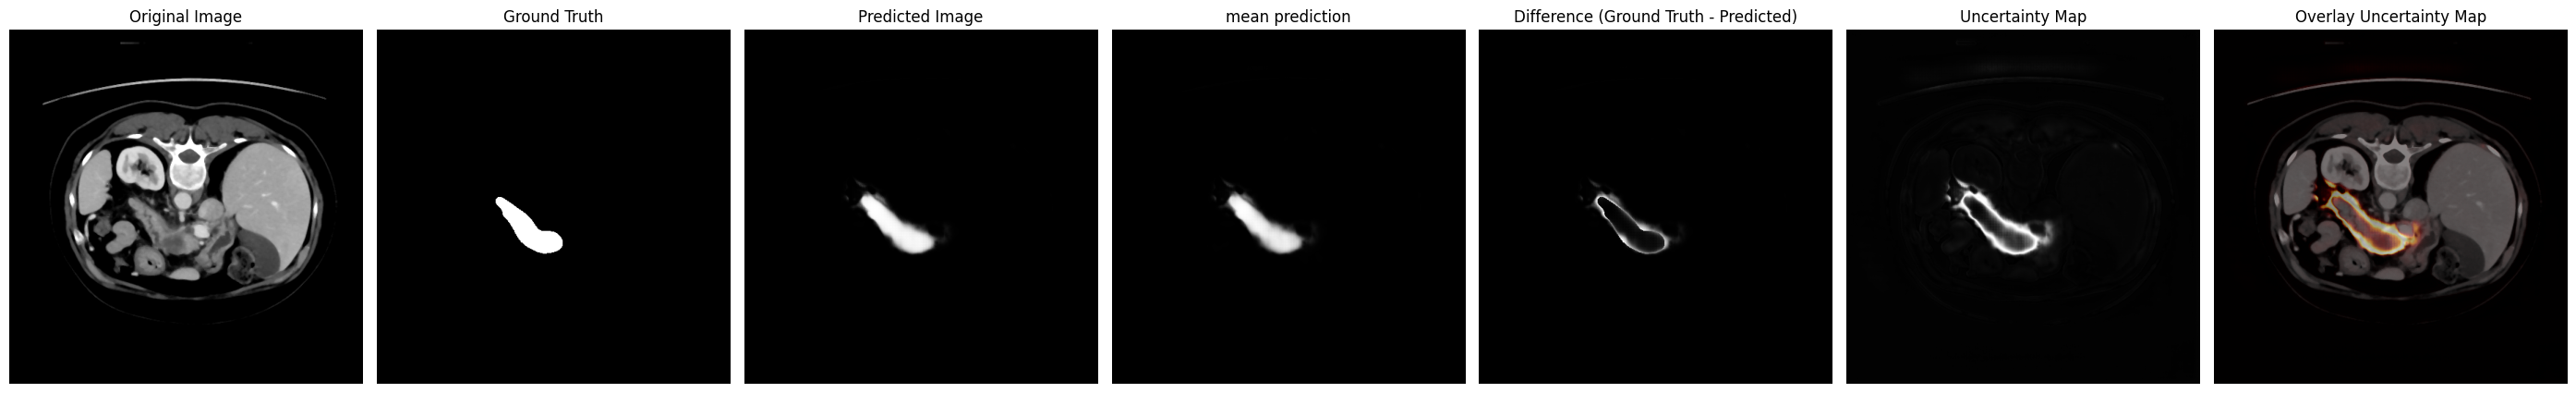

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def plot_overlay_uncertainty(ax, image, uncertainty_map, title="Overlay Uncertainty Map"):
    ax.imshow(image, cmap='gray')  # Show the original image in grayscale
    ax.imshow(uncertainty_map, cmap='afmhot', alpha=0.5)  # Overlay uncertainty map
    ax.set_title(title)
    ax.axis('off')  # Turn off axis labels

# Assuming x_val, y_val, y_pred, and uncertainty_map_np are already defined

for i in range(0, 4, 1):
    fig, ax = plt.subplots(1, 7, figsize=(28, 7))  # Adjusted to 6 subplots in a 1x6 grid

    # Original image
    ax[0].imshow(x_eval[q[i], :, :], cmap='gray')
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    # Ground truth
    ax[1].imshow(y_eval[q[i], :, :], cmap='gray')
    ax[1].set_title('Ground Truth')
    ax[1].axis('off')

    # Predicted image
    ax[2].imshow(y_pred[q[i], :, :], cmap='gray')
    ax[2].set_title('Predicted Image')
    ax[2].axis('off')

    # Uncertainty map
    uncertainty_slice = uncertainty_maps[q[i]]  # Access the corresponding uncertainty slice
    ax[5].imshow(uncertainty_slice, cmap='gray')
    ax[5].set_title('Uncertainty Map')
    ax[5].axis('off')

    # Difference between ground truth and predicted image
    difference = np.abs(np.squeeze(y_eval[q[i], :, :]) - np.squeeze(y_pred[q[i], :, :]))

    ax[4].imshow(difference, cmap='gray')
    ax[4].set_title('Difference (Ground Truth - Predicted)')
    ax[4].axis('off')

    ax[3].imshow(mean_predictions[q[i]], cmap='gray')
    ax[3].set_title('mean prediction')
    ax[3].axis('off')


    # Overlay Uncertainty Map on Original Image
    plot_overlay_uncertainty(ax[6], x_eval[q[i], :, :], uncertainty_slice, "Overlay Uncertainty Map")

    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()


In [41]:
mean_predictions.shape

(5534, 512, 512)

In [42]:
uncertainty_maps


array([[[0.00577148, 0.0066658 , 0.00406145, ..., 0.00394999,
         0.00484359, 0.00364868],
        [0.00534211, 0.00686889, 0.00477029, ..., 0.00473855,
         0.00522891, 0.00314781],
        [0.00409033, 0.00681902, 0.00542064, ..., 0.00661301,
         0.00501614, 0.00250266],
        ...,
        [0.00503128, 0.00799358, 0.00645981, ..., 0.00590682,
         0.0050621 , 0.00257588],
        [0.00689223, 0.01119739, 0.00687986, ..., 0.00589999,
         0.00628925, 0.00338724],
        [0.00546234, 0.00671814, 0.00473446, ..., 0.00361556,
         0.00487043, 0.00355202]],

       [[0.00601586, 0.00686178, 0.00408501, ..., 0.00373167,
         0.00469312, 0.00377023],
        [0.00553946, 0.00712654, 0.00474341, ..., 0.00469414,
         0.00526856, 0.00330844],
        [0.00420136, 0.00677944, 0.00538096, ..., 0.00644684,
         0.00502769, 0.00255844],
        ...,
        [0.00513348, 0.00817383, 0.00650552, ..., 0.00616225,
         0.0051974 , 0.0026437 ],
        [0.0

In [43]:
uncertainty_maps.shape

(5534, 512, 512)

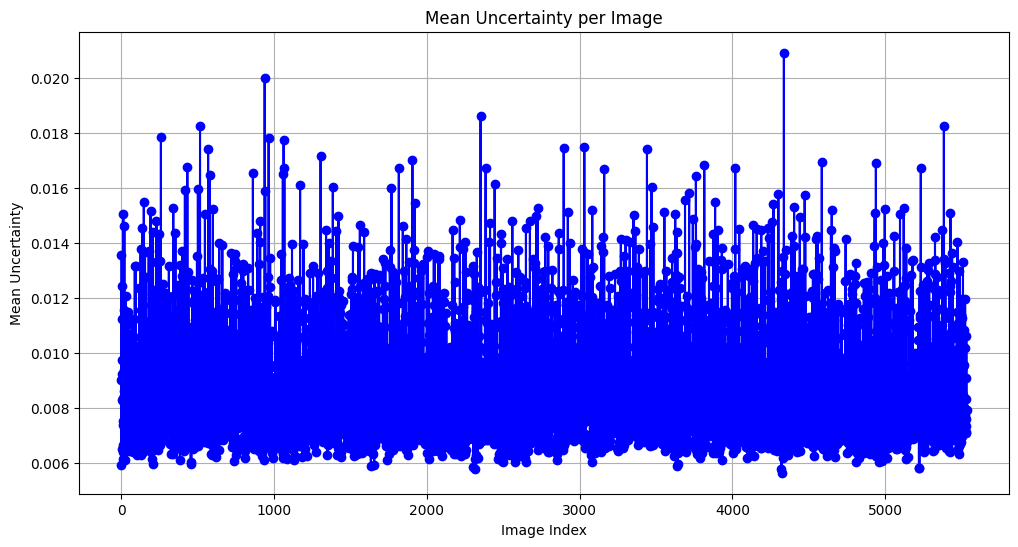

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming `uncertainty_map` is your array of shape (5534, 512, 512)
# Step 1: Compute the mean uncertainty for each image
mean_uncertainty_per_image = np.mean(uncertainty_maps, axis=(1, 2))  # Shape: (5534,)

# Step 2: Plot the uncertainty values against the image index
plt.figure(figsize=(12, 6))
plt.plot(range(len(mean_uncertainty_per_image)), mean_uncertainty_per_image, marker='o', linestyle='-', color='b')
plt.title("Mean Uncertainty per Image")
plt.xlabel("Image Index")
plt.ylabel("Mean Uncertainty")
plt.grid(True)
plt.show()


In [45]:
mean_uncertainty_per_image.shape

(5534,)

In [46]:
import numpy as np
  # Example array (replace with your own data)

# Save the array to a CSV file
np.savetxt(f"{loss}_uncertainty_pancreas.csv", mean_uncertainty_per_image, delimiter=",")


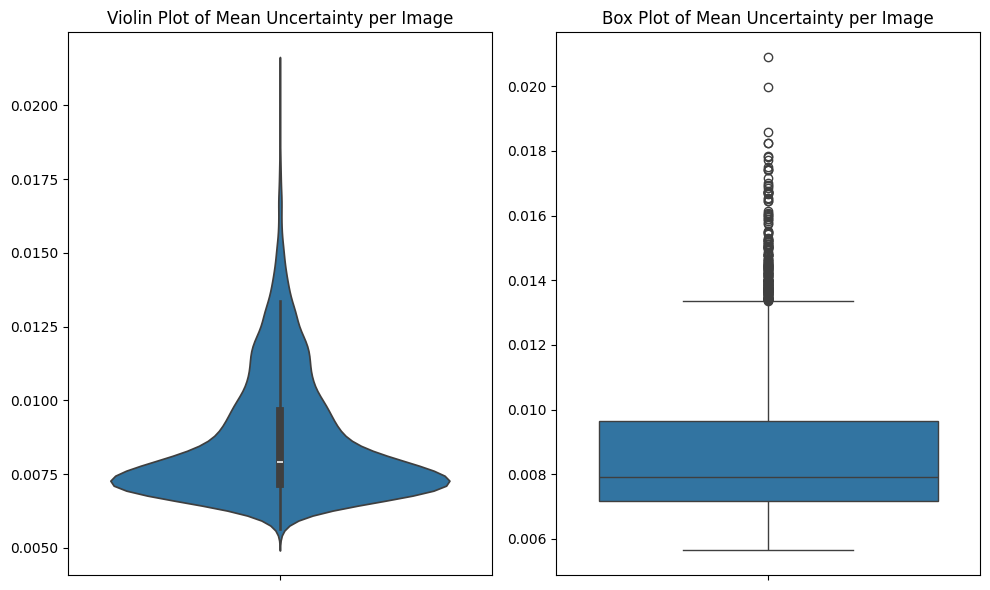

In [47]:
# Required libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your data is stored in mean_uncertainty_per_image
# mean_uncertainty_per_image = your_actual_array

# Initialize the figure
plt.figure(figsize=(10, 6))

# Create a subplot for both violin and box plots
plt.subplot(1, 2, 1)
sns.violinplot(y=mean_uncertainty_per_image)
plt.title("Violin Plot of Mean Uncertainty per Image")

plt.subplot(1, 2, 2)
sns.boxplot(y=mean_uncertainty_per_image)
plt.title("Box Plot of Mean Uncertainty per Image")

# Adjust layout for better spacing
plt.tight_layout()

# Show the plots
plt.show()


In [48]:
uncertainty_maps.shape

(5534, 512, 512)

In [49]:
a=uncertainty_maps[0]

In [50]:
a.shape

(512, 512)

In [51]:
loss

'logcosh'